# Gulf Dissolved Oxygen - 2024 & 2025 #

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [14]:
gulf_do_df = pd.read_csv('GulfHypoxia_2024to2025.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'GulfHypoxia_2024to2025.csv'

In [4]:
gulf_do_df.head()

,SHIP,CRUISE,STATION,DATE,longitd,latitud,oxygen,LEG,TIME,CAST,BOTDEPTH_M,WATERDEPTH
0,OREGON II,352,1,6/4/24,-89.996833,28.501333,4.0673,1,18:20:56,1,103,101.00
1,OREGON II,352,2,6/4/24,-90.121500,28.363000,4.4879,1,21:53:52,1,76,78.00
2,OREGON II,352,3,6/5/24,-90.173667,28.302833,4.8144,1,1:08:48,1,85,87.00
3,OREGON II,352,4,6/5/24,-90.609333,28.354167,6.5312,1,7:38:23,1,49,49.80
4,OREGON II,352,5,6/5/24,-90.967667,28.324667,5.0777,1,14:20:09,1,57,58.67


In [5]:
# convert to geopandas
gulf_do_gdf = gpd.GeoDataFrame(
    gulf_do_df, geometry=gpd.points_from_xy(gulf_do_df.longitd, gulf_do_df.latitud), crs="EPSG:4326"
)

/tmp/ipykernel_201/3619902339.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


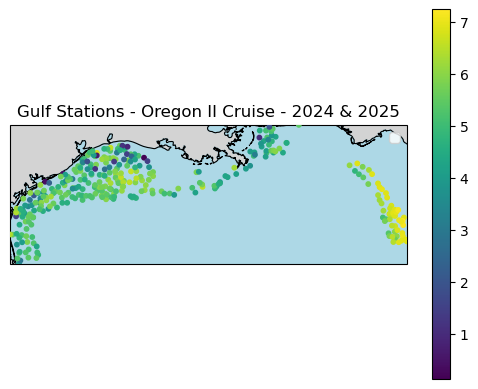

In [8]:
# Define the Cartopy projection for the map display
projection = ccrs.PlateCarree() 

# Create a figure and a GeoAxes object
fig, ax = plt.subplots(subplot_kw={'projection': projection})

# Add map features to the axes (coastlines, borders)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.6)
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')

# Plot the GeoDataFrame points onto the Cartopy axes
# Use transform=ccrs.PlateCarree() to tell Cartopy the source CRS of your data
# (even if it matches the axes projection, it's good practice)
gulf_do_gdf.plot(ax=ax, 
                 marker='o', 
                 markersize=10, 
                 transform=ccrs.PlateCarree(), 
                 zorder=10,
                 column='oxygen',
                legend=True)

min_lon = gulf_do_df['longitd'].min()
max_lon = gulf_do_df['longitd'].max()
min_lat = gulf_do_df['latitud'].min()
max_lat = gulf_do_df['latitud'].max()

# Set the extent of the map (optional, adjusts view)
ax.set_extent([min_lon, max_lon, min_lat, max_lat],crs=ccrs.PlateCarree())

ax.legend(loc='best')

# Display the map
plt.title("Gulf Stations - Oregon II Cruise - 2024 & 2025")
plt.show()

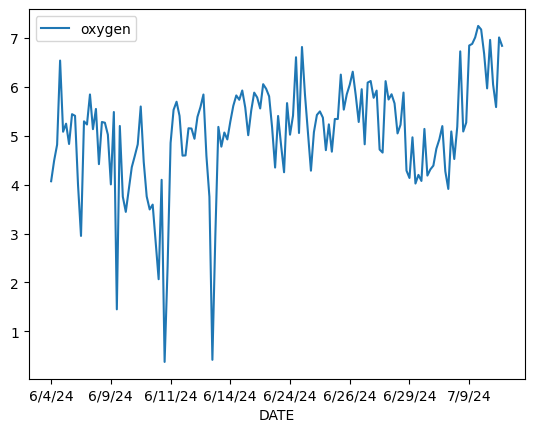

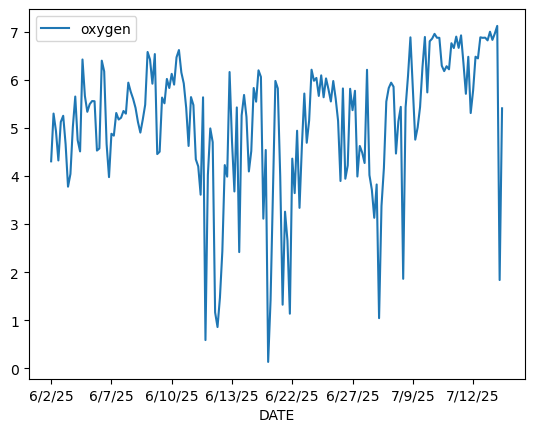

In [7]:
# Plot timeseries of measurements (by cruise)
for c in gulf_do_df['CRUISE'].drop_duplicates():
    gulf_do_df_cruise = gulf_do_df[gulf_do_df['CRUISE']==c]
    gulf_do_df_cruise.plot(x='DATE',y='oxygen')

In [10]:
uxs_do_df = pd.read_csv("hypoxia_casts_2026-01-27.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'hypoxia_casts_2026-01-27.csv'